In [1]:
# Update package list + install Python 3.10
# ! apt-get update -y
# ! apt-get install python3.10 python3.10-distutils -y

# # Download pip for Python 3.10
# ! curl https://bootstrap.pypa.io/get-pip.py -o get-pip.py
# ! python3.10 get-pip.py

# # Swap kernels to Python 3.10
%pip install ipykernel
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
model_checkpoint = "facebook/dinov2-base" # pre-trained model from which to fine-tune
batch_size = 32 # batch size for training and evaluation

In [3]:
%pip install evaluate datasets scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install -U accelerate
%pip install -U transformers

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [5]:
from huggingface_hub import notebook_login

notebook_login()

In [6]:
%%capture
%sudo apt -qq install git-lfs
%git config --global credential.helper store

In [7]:
%pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [8]:
import sys

In [1]:
# import os
# import pandas as pd
# from datasets import Dataset, DatasetDict, Features, Image, ClassLabel
# import kagglehub
from datasets import load_dataset
dataset = load_dataset("imagefolder", data_dir="/data/team01/ds340w/datasets/ham10000_split")

# path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
# image_dir = os.path.join(path, "ham10000_images_part_1")
# df = pd.read_csv(os.path.join(path, "HAM10000_metadata.csv"))

# # Map image IDs to  file paths
# df['image'] = df['image_id'].apply(lambda x: os.path.join(image_dir, f"{x}.jpg"))

# # Filter for part_1 (~5000 images)
# df = df[df['image'].apply(os.path.exists)].reset_index(drop=True)

# # Create Dataset with specific Features
# features = Features({
#     "image": Image(),
#     "dx": ClassLabel(names=list(df['dx'].unique()))
# })

# raw_dataset = Dataset.from_pandas(df[['image', 'dx']], features=features)
# cleaned_dataset = raw_dataset.rename_column("dx", "label")
# dataset = DatasetDict({
#     'train': cleaned_dataset
# })

# print(dataset)

Resolving data files:   0%|          | 0/7010 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2004 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [2]:
import evaluate

metric = evaluate.load("accuracy")

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 7010
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 2004
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1001
    })
})

In [4]:
dataset["train"].features

{'image': Image(mode=None, decode=True),
 'label': ClassLabel(names=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'])}

In [13]:
example = dataset["train"][10]
example

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450>,
 'label': 0}

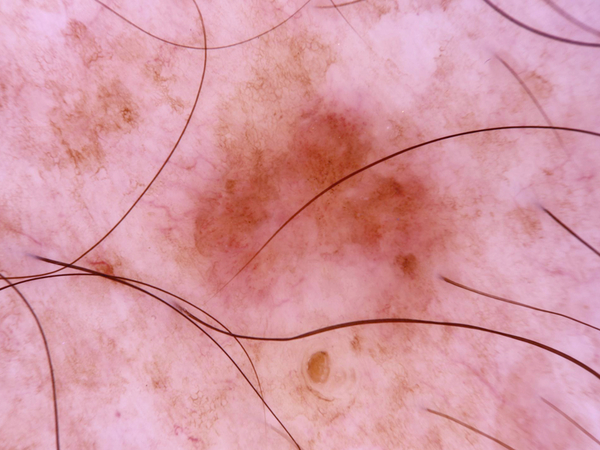

In [14]:
example['image']

In [15]:
example['label']

0

In [16]:
dataset["train"].features["label"]

ClassLabel(names=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'])

In [17]:
labels = dataset["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

id2label[2]

'bkl'

In [18]:
from transformers import AutoImageProcessor

image_processor  = AutoImageProcessor.from_pretrained(model_checkpoint)
image_processor

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


BitImageProcessorFast {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "data_format": "channels_first",
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "BitImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 256
  }
}

In [19]:
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
if "height" in image_processor.size:
    size = (image_processor.size["height"], image_processor.size["width"])
    crop_size = size
    max_size = None
elif "shortest_edge" in image_processor.size:
    size = image_processor.size["shortest_edge"]
    crop_size = (size, size)
    max_size = image_processor.size.get("longest_edge")

train_transforms = Compose(
        [
            RandomResizedCrop(crop_size),
            RandomHorizontalFlip(),
            ToTensor(),
            normalize,
        ]
    )

val_transforms = Compose(
        [
            Resize(size),
            CenterCrop(crop_size),
            ToTensor(),
            normalize,
        ]
    )

def preprocess_train(example_batch):
    """Apply train_transforms across a batch."""
    example_batch["pixel_values"] = [
        train_transforms(image.convert("RGB")) for image in example_batch["image"]
    ]
    return example_batch

def preprocess_val(example_batch):
    """Apply val_transforms across a batch."""
    example_batch["pixel_values"] = [val_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch

In [20]:
# split up training into training + validation
# splits = dataset["train"].train_test_split(test_size=0.1)
# train_ds = splits['train']
# val_ds = splits['test']

In [21]:
train_ds.set_transform(preprocess_train)
val_ds.set_transform(preprocess_val)

In [22]:
train_ds[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450>,
 'label': 5,
 'pixel_values': tensor([[[1.1187, 1.1187, 1.1358,  ..., 1.2385, 1.2043, 1.1872],
          [1.1358, 1.1358, 1.1358,  ..., 1.2728, 1.2557, 1.2385],
          [1.1358, 1.1358, 1.1358,  ..., 1.2899, 1.2899, 1.3070],
          ...,
          [1.1358, 1.1358, 1.1358,  ..., 0.7933, 0.7419, 0.7077],
          [1.1187, 1.1187, 1.1358,  ..., 0.8104, 0.7762, 0.7762],
          [1.0844, 1.1015, 1.1187,  ..., 0.8276, 0.8104, 0.8104]],
 
         [[0.9230, 0.9230, 0.9405,  ..., 1.0105, 0.9755, 0.9580],
          [0.9055, 0.9055, 0.9055,  ..., 1.0280, 1.0105, 0.9930],
          [0.8880, 0.8880, 0.8880,  ..., 1.0455, 1.0455, 1.0455],
          ...,
          [0.9405, 0.9405, 0.9405,  ..., 0.3102, 0.2752, 0.2752],
          [0.9405, 0.9405, 0.9580,  ..., 0.3452, 0.3277, 0.3277],
          [0.9405, 0.9580, 0.9755,  ..., 0.3803, 0.3803, 0.3803]],
 
         [[1.3328, 1.3328, 1.3502,  ..., 1.4548, 1.4200, 1.4025],
  

In [23]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer

model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes = True, # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2ForImageClassification LOAD REPORT from: facebook/dinov2-base
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [24]:
import accelerate
import transformers

transformers.__version__, accelerate.__version__

('5.3.0', '1.13.0')

In [25]:
model_name = model_checkpoint.split("/")[-1]

args = TrainingArguments(
    f"dinov2-base-rawdata-finetuned-SkinDisease",
    remove_unused_columns=False,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=batch_size,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=10,
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=True,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [26]:
import numpy as np

# the compute_metrics function takes a Named Tuple as input:
# predictions, which are the logits of the model as Numpy arrays,
# and label_ids, which are the ground-truth labels as Numpy arrays.
def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions"""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

In [27]:
import torch

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [28]:
trainer = Trainer(
    model,
    args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

In [29]:
train_results = trainer.train()
# rest is optional but nice to have
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.739809,1.938334,0.300499
2,0.900034,0.756768,0.726933
3,0.681447,0.730352,0.740648
4,0.561448,0.529097,0.809227
5,0.443957,0.634359,0.769327
6,0.398590,0.380043,0.856608
7,0.318369,0.430489,0.840399
8,0.281575,0.379220,0.847880
9,0.247528,0.349547,0.861596
10,0.198550,0.308956,0.884040


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

***** train metrics *****
  epoch                    =         10.0
  total_flos               = 6859015501GF
  train_loss               =       0.5779
  train_runtime            =   0:11:01.62
  train_samples_per_second =      108.974
  train_steps_per_second   =        0.227


RuntimeError: on_train_begin must be called before on_evaluate

In [ ]:
metrics = trainer.evaluate()
# some nice to haves:
trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)

In [30]:
# metrics = trainer.evaluate()
# # some nice to haves:
# trainer.log_metrics("eval", metrics)
# trainer.save_metrics("eval", metrics)

In [31]:
trainer.push_to_hub()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/RumiaKit/dinov2-base-rawdata-finetuned-SkinDisease/commit/831b76e86a0d0670da360bf4933c9364c4d80dd0', commit_message='End of training', commit_description='', oid='831b76e86a0d0670da360bf4933c9364c4d80dd0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/RumiaKit/dinov2-base-rawdata-finetuned-SkinDisease', endpoint='https://huggingface.co', repo_type='model', repo_id='RumiaKit/dinov2-base-rawdata-finetuned-SkinDisease'), pr_revision=None, pr_num=None)

In [32]:
# test_ds

In [33]:
from transformers import AutoModelForImageClassification, AutoImageProcessor
from sklearn.metrics import accuracy_score
import torch

# Load the pre-trained model and image processor
# repo_name = "Jayanth2002/dinov2-base-rawdata-finetuned-SkinDisease"
# image_processor = AutoImageProcessor.from_pretrained(repo_name)
# model = AutoModelForImageClassification.from_pretrained(repo_name)

# Load and preprocess the test images
test_data_dir = "/data/team01/ds340w/datasets/ham10000_split/test"  # Path to the test data directory
test_images = load_dataset("imagefolder", data_dir=test_data_dir)

# Preprocess the test images
test_images.set_transform(preprocess_val)  # Use the same validation transforms

# Create a test dataset
test_ds = test_images["train"]  # Use the "train" split for the test data





Resolving data files:   0%|          | 0/2003 [00:00<?, ?it/s]

In [34]:
### ERROR: Model is living on GPU (CUDA), but image data is still on CPU.

# 1. Determine the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Good practice: set model to evaluation mode
print(f"Using device: {device}")

# Initialize lists to store predicted and actual labels
predicted_labels = []
actual_labels = []

# Iterate through the test dataset and make predictions
for example in test_ds:
    image = example["image"]
    
    # 2. Process the image (This creates tensors on the CPU by default)
    encoding = image_processor(image.convert("RGB"), return_tensors="pt")

    # 3. MOVE THE IMAGES TO GPU
    # We loop through the dictionary and move each tensor to the GPU
    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        # 4. Now both the model and the encoding are on the same device
        outputs = model(**encoding)
        logits = outputs.logits

    # 5. Bring the result back to CPU to extract the number
    predicted_class_idx = logits.argmax(-1).item()
    predicted_labels.append(predicted_class_idx)
    actual_labels.append(example["label"])

# Calculate accuracy
accuracy = accuracy_score(actual_labels, predicted_labels)
print(f"Test Accuracy: {accuracy:.4f}")

Using device: cuda
Test Accuracy: 0.8992
